# you only look once (YOLO) [🚧 WIP]

Ultralytics supports a wide range of YOLO models, from early versions like [YOLOv3](https://docs.ultralytics.com/models/yolov3/) to the latest [YOLO11](https://docs.ultralytics.com/models/yolo11/). the latest version of the acclaimed real-time object detection and image segmentation model `YOLO11` models pretrained on the [COCO](https://docs.ultralytics.com/datasets/detect/coco/) dataset for [Detection](https://docs.ultralytics.com/tasks/detect/), [Segmentation](https://docs.ultralytics.com/tasks/segment/), and [Pose Estimation](https://docs.ultralytics.com/tasks/pose/). Additionally, [Classification](https://docs.ultralytics.com/tasks/classify/) models pretrained on the [ImageNet](https://docs.ultralytics.com/datasets/classify/imagenet/) dataset are available. [Tracking](https://docs.ultralytics.com/modes/track/) mode is compatible with all Detection, Segmentation, and Pose models. All [Models](https://docs.ultralytics.com/models/) are automatically downloaded from the latest Ultralytics [release](https://github.com/ultralytics/assets/releases) upon first use.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
import torch
import random

In [6]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [5]:
# Initialize detection model
from ultralytics import YOLO
yolo_model = YOLO("yolov8n.pt") 

In [6]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://ultralytics.com/images/bus.jpg' save=True

Ultralytics 8.3.4 🚀 Python-3.12.4 torch-2.4.1 CPU (Apple M3 Max)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

100%|█████████████████████████████████████████| 134k/134k [00:00<00:00, 215MB/s]
image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 29.8ms
Speed: 1.6ms preprocess, 29.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /Users/n0man/Code/n03an.me/runs/detect/predict7
💡 Learn more at https://docs.ultralytics.com/modes/predict


set up the device (mps for macOS, cuda for NVIDIA GPUs, or cpu for CPU-only inference)

In [17]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
# Run detection
def detect_objects(image_path):
    results = yolo_model(image_path)
    # Visualize results
    plt.figure(figsize=(12, 8))
    plt.imshow(results[0].plot()[:, :, ::-1])  # Convert BGR to RGB
    plt.title("Object Detection")
    plt.axis('off')
    plt.show()


image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/images/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 24.7ms
Speed: 1.3ms preprocess, 24.7ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)


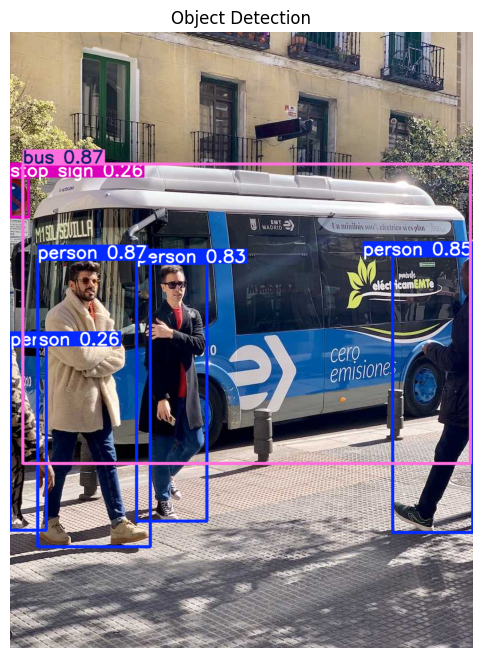

In [7]:
# Run detection
detect_objects("images/bus.jpg")


### Detecting Events

Will try somethin rubbish - the function `detect_event` takes the results from the YOLO model and checks for the presence of specific classes (like "person") to determine interesting event. If there are more than 3 people, it flags it as "fighting", and if there are 5 or more, it flags it as a "crowd" situation 🤦🏻‍♂️🤦🏻‍♂️🤦🏻‍♂️ as rubbish as it could get but you get the point...

In [8]:
FIRE_CLASSES = ["fire", "smoke"]
CROWD_THRESHOLD = 5

def detect_event(yolo_results):
    people_count = 0
    fire_detected = False

    for det in yolo_results.boxes:
        cls = int(det.cls[0])
        label = yolo_model.names[cls]

        if label == "person":
            people_count += 1
        elif label in FIRE_CLASSES:
            fire_detected = True

    fighting_detected = people_count >= 3 and not fire_detected
    overcrowded = people_count >= CROWD_THRESHOLD

    return fire_detected, fighting_detected, overcrowded, people_count

we will use lightweight BLIP model `Salesforce/blip-image-captioning-base` (possibly the one that could run on Jetson edge devies like Jetson Xavier NX??) to generate image captions.

In [18]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image as PILImage

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base", 
    device_map="auto", 
    trust_remote_code=True, 
    use_safetensors=True  # <--- this avoids torch.load
)

def generate_caption(frame):
    pil_image = PILImage.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    inputs = blip_processor(images=pil_image, return_tensors="pt")

    inputs = {k: v.to(device) for k, v in inputs.items()}
    output = blip_model.generate(**inputs, max_new_tokens=50)
    caption = blip_processor.batch_decode(output, skip_special_tokens=True)[0]
    return caption


## Detecting Events and Captions...


image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/images/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 34.6ms
Speed: 2.4ms preprocess, 34.6ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)


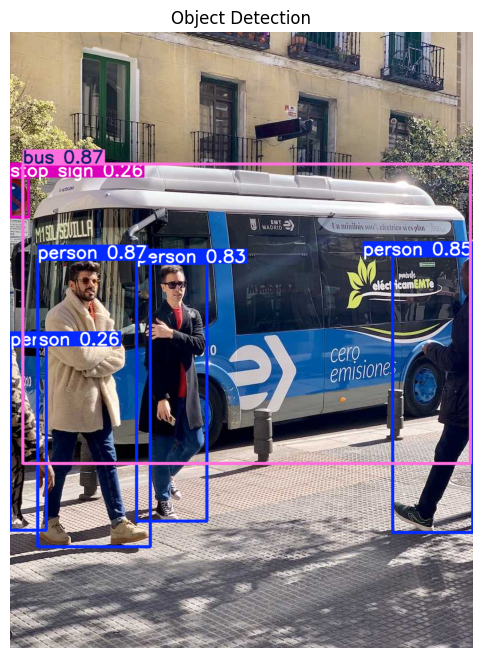


0: 640x480 4 persons, 1 bus, 1 stop sign, 21.7ms
Speed: 1.1ms preprocess, 21.7ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)

[EVENT DETECTED]
🔴 Possible fighting detected
Captions : a group of people walking around a bus


In [19]:
image_path = "images/bus.jpg"
frame = cv2.imread(image_path)
detect_objects(image_path)

results = yolo_model(frame)[0]
fire, fight, crowd, count = detect_event(results)

if fire or fight or crowd:
    print("\n[EVENT DETECTED]")
    if fire: print("🔥 Fire detected")
    if fight: print("🔴 Possible fighting detected")
    if crowd: print(f"👯👯👯👯 Overcrowding detected ({count} people)")

    caption = generate_caption(frame)
    print(f"Captions : {caption}")
else:
    print("✅ No major event detected in the image.")


image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/images/park.jpg: 384x640 8 persons, 1 bicycle, 1 dog, 26.7ms
Speed: 1.5ms preprocess, 26.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)


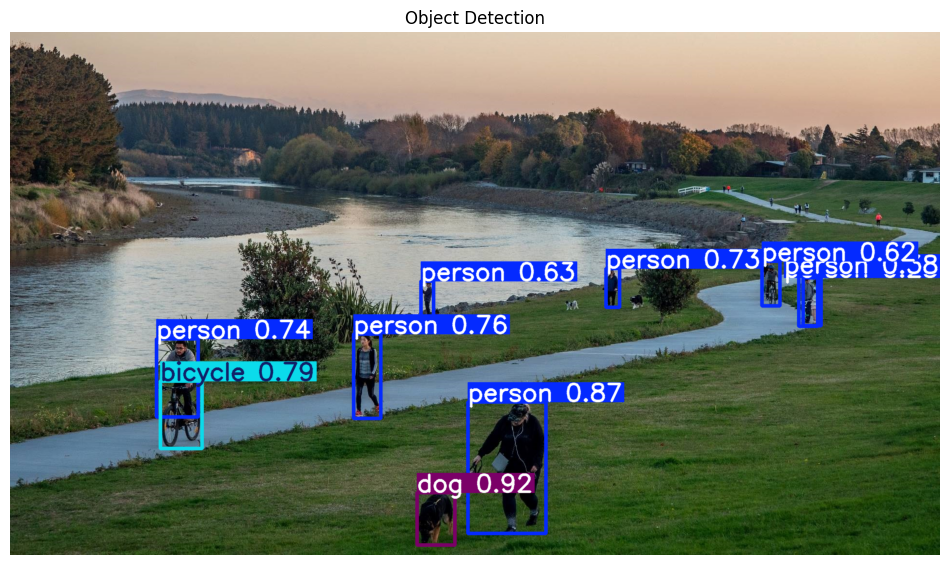


0: 384x640 8 persons, 1 bicycle, 1 dog, 17.2ms
Speed: 1.3ms preprocess, 17.2ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

[EVENT DETECTED]
🔴 Possible fighting detected
👯👯👯👯 Overcrowding detected (8 people)
Captions : a group of people walking along a river


In [20]:
image_path = "images/park.jpg"
frame = cv2.imread(image_path)
detect_objects(image_path)

results = yolo_model(frame)[0]
fire, fight, crowd, count = detect_event(results)

if fire or fight or crowd:
    print("\n[EVENT DETECTED]")
    if fire: print("🔥 Fire detected")
    if fight: print("🔴 Possible fighting detected")
    if crowd: print(f"👯👯👯👯 Overcrowding detected ({count} people)")

    caption = generate_caption(frame)
    print(f"Captions : {caption}")
else:
    print("✅ No major event detected in the image.")